In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from shapely.geometry import Point
import fiona
import rasterio
import json

print("Loaded libraries successfully.")

Loaded libraries successfully.


## Data Sources

**GEDI Data (Para State):**
- GeoJSON boundary: https://github.com/giuliano-macedo/geodata-br-states/blob/main/geojson/br_states/br_pa.json
- Used in `VegMapper/gedi/gedi_l2a_arset.ipynb` to filter GEDI shots for Para state only

**PRODES Deforestation Data:**
- Source: https://terrabrasilis.dpi.inpe.br/geonetwork/srv/eng/catalog.search#/metadata/507294db-a789-42dd-9158-9dea77d9293f
- Raster format (GeoTIFF) with land cover classifications for Legal Amazon

In [4]:
# take in paths for files (gedi and prodes)
gedi = input("Enter path to GEDI file (.csv): ")
prodes = input("Enter path to PRODES raster file (.tif): ")

lat_col, lon_col = 'latitude', 'longitude'  # specify the column names for latitude and longitude

gedi_df = pd.read_csv(gedi)
raster = rasterio.open(prodes)

In [5]:
# Explore raster data
print("Raster CRS:", raster.crs)
print("Raster metadata:", raster.meta)


Raster CRS: EPSG:4674
Raster metadata: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 255.0, 'width': 333767, 'height': 259043, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4674"]]'), 'transform': Affine(9e-05, 0.0, -73.99092215899995,
       0.0, -9e-05, 5.272190833000034)}


In [10]:
# Essentially puts a bounding box around the raster data for only the area of interest (Para in our case)
def bound_raster(raster, lat_min, lat_max, lon_min, lon_max):
    """Function to bound raster to given lat/lon extent."""
    from rasterio.warp import transform_bounds
    from rasterio.windows import from_bounds
    from rasterio.windows import Window

    lon_min, lat_min, lon_max, lat_max = transform_bounds(src_crs = 'EPSG:4326',
                                                          dst_crs = raster.crs,
                                                          left=lon_min, bottom=lat_min,
                                                          right=lon_max, top=lat_max)

    window = from_bounds(lon_min, lat_min, lon_max, lat_max, raster.transform)

    # col_off and row_off from left edge (in pixels) must be integers - round_off()
    # window width and height must be integers - round_lengths() - round up
    window = window.round_offsets().round_lengths(op = 'ceil') 

    # in case the new window exceeds raster bounds, we can adjust it
    
    full_win = Window(col_off=0, row_off=0, width=raster.width, height=raster.height)
    win = window.intersection(full_win)

    # read the pixel values within the window
    data = raster.read(window=win)
    
    # transform the new window to start at (0,0) at the top-left corner rather than random pixel from the original coordinates
    transform = raster.window_transform(win)

    return data, transform


## Run the below code for **PARA**

In [ ]:
lat_min_para = -10 # −9.883333
lat_max_para = 3 # 2.616667
lon_min_para = -59 # −58.883333
lon_max_para = -46 # −46.050000 

print("Bounding box:")
print(f"    Lat: {lat_min_para} to {lat_max_para}")
print(f"    Lon: {lon_min_para} to {lon_max_para}")

cropped_raster, cropped_transform = bound_raster(raster, lat_min_para, lat_max_para, lon_min_para, lon_max_para)
# We know that the GEDI points will already be cropped to Para region, so no need to filter them again


Bounding box:
    Lat: -10 to 3
    Lon: -59 to -46
Original raster size: 333767 x 259043 pixels
Cropped raster size: 144444 x 1 pixels


## Run the below code for **Acre**


In [ ]:
lat_min_acre = -12
lat_max_acre = -7 
lon_min_acre = -74
lon_max_acre = -66

print("Bounding box:")
print(f"    Lat: {lat_min_acre} to {lat_max_acre}")
print(f"    Lon: {lon_min_acre} to {lon_max_acre}")

cropped_raster, cropped_transform = bound_raster(raster, lat_min_acre, lat_max_acre, lon_min_acre, lon_max_acre)

# We know that the GEDI points will already be cropped to Para region, so no need to filter them again

Bounding box:
    Lat: -12 to -7
    Lon: -74 to -66


In [18]:
# Confirm cropping was successful
print(f"Original raster size: {raster.width} x {raster.height} pixels")

if cropped_raster.ndim == 2:
    height, width = cropped_raster.shape
    bands = 1
else:
    bands, height, width = cropped_raster.shape

print(f"Cropped raster size: {width} x {height} pixels with {bands} band(s)")

Original raster size: 333767 x 259043 pixels
Cropped raster size: 88788 x 55556 pixels with 1 band(s)


In [ ]:
# Create one full dataframe with GEDI points and corresponding PRODES pixel values
coords_list = []

for lon, lat in zip(gedi_df[lon_col], gedi_df[lat_col]):
    coords_list.append((lon, lat))

land_cover_list = rasterio.sample.sample_gen(raster, coords_list)

gedi_df['prodes_pixel'] = [val[0] for val in land_cover_list]


# remove points with no data (255, according to the metadata: 'nodata': 255.0)
print("Total GEDI points before filtering:", len(gedi_df))
gedi_df = gedi_df[gedi_df['prodes_pixel'] != 255]
print(len(gedi_df), "GEDI points remain after filtering out no-data PRODES pixels.")

# see how many unique prodes pixel values we have
print("Unique PRODES pixel values in GEDI data:", gedi_df['prodes_pixel'].unique())

118389 GEDI points remain after filtering out no-data PRODES pixels.


In [29]:
prodes_classes = {
    # Deforestation by year
    0: "Deforestation 2000", 2: "Deforestation 2002", 4: "Deforestation 2004",
    6: "Deforestation 2006", 7: "Deforestation 2007", 8: "Deforestation 2008",
    9: "Deforestation 2009", 10: "Deforestation 2010", 11: "Deforestation 2011",
    12: "Deforestation 2012", 13: "Deforestation 2013", 14: "Deforestation 2014",
    15: "Deforestation 2015", 16: "Deforestation 2016", 17: "Deforestation 2017",
    18: "Deforestation 2018", 19: "Deforestation 2019", 20: "Deforestation 2020",
    21: "Deforestation 2021", 22: "Deforestation 2022", 23: "Deforestation 2023",
    24: "Deforestation 2024",
    # Residual/degraded areas
    50: "Residual 2010", 51: "Residual 2011", 52: "Residual 2012",
    53: "Residual 2013", 54: "Residual 2014", 55: "Residual 2015",
    56: "Residual 2016", 57: "Residual 2017", 58: "Residual 2018",
    59: "Residual 2019", 60: "Residual 2020", 61: "Residual 2021",
    62: "Residual 2022", 63: "Residual 2023", 64: "Residual 2024",
    # Main categories
    91: "Water", 100: "Forest", 101: "Non-Forest"
}

broad_prodes_classes = {}
for k in list(range(0, 25)):
    broad_prodes_classes[k] = "Deforested"
for k in list(range(50, 65)):
    broad_prodes_classes[k] = "Degraded"
broad_prodes_classes[91] = "Water"
broad_prodes_classes[100] = "Forest"
broad_prodes_classes[101] = "Non-Forest"

gedi_df['prodes_class'] = gedi_df['prodes_pixel'].map(prodes_classes)
gedi_df['broad_prodes_class'] = gedi_df['prodes_pixel'].map(broad_prodes_classes)

In [ ]:
# Actual histogram creation
land_types = gedi_df['broad_prodes_class'].dropna().unique()

for land_type in land_types:
    subset = gedi_df[gedi_df['broad_prodes_class'] == land_type]
    

5


## Below is all old code for when we were using .gpkg files for PRODES data

In [6]:
# geopandas doesn't load all layers by default, so we need to read each layer and concatenate 🤦‍♂️

layers = fiona.listlayers(prodes)
print(f"Available layers in GPKG: {layers}")

all_prodes_layers = []
for layer in layers:
    print(f"Reading layer: {layer}")
    layer_gdf = gpd.read_file(prodes, layer=layer)
    layer_gdf['layer_source'] = layer  # add a column to identify the source
    all_prodes_layers.append(layer_gdf)

prodes_df = gpd.GeoDataFrame(pd.concat(all_prodes_layers, ignore_index=True))
print(f"Main class values: {prodes_df['main_class'].unique()}")

Available layers in GPKG: ['accumulated_deforestation_2007', 'hydrography', 'yearly_deforestation', 'no_forest', 'residual']
Reading layer: accumulated_deforestation_2007
Reading layer: hydrography
Reading layer: yearly_deforestation
Reading layer: no_forest
Reading layer: residual
Main class values: ['DESMATAMENTO' 'HIDROGRAFIA' 'NAO_FLORESTA' 'RESIDUO']


In [10]:
# print all states in prodes_df
print("States in PRODES data:", prodes_df['state'].unique()) 

# get number of rows for each state
state_counts = prodes_df['state'].value_counts()
print("Number of rows for each state in PRODES data:\n", state_counts)

# chose "AC" (Acre) as state to test histograms on since it had 24k rows of data
acre_prodes = prodes_df[prodes_df['state'] == 'AC']

States in PRODES data: ['RR' 'PA' 'AM' 'MA' 'MT' 'TO' 'AC' 'RO' 'AP' 'MS']
Number of rows for each state in PRODES data:
 state
PA    480247
AM    165529
MT    134322
AC    103564
RO    102472
MA     81719
RR     53108
AP     19078
TO      9986
MS         2
Name: count, dtype: int64


In [12]:
for layer in layers:
    print(f"\nReading '{layer}':")
    with fiona.open(prodes, layer=layer) as lyr:
        print(lyr.schema)
        print(f"CRS is: {lyr.crs}")


Reading 'accumulated_deforestation_2007':
{'properties': {'state': 'str:99', 'path_row': 'str:20', 'main_class': 'str:255', 'class_name': 'str:255', 'def_cloud': 'float', 'julian_day': 'int32', 'image_date': 'date', 'year': 'float', 'area_km': 'float', 'scene_id': 'int32', 'source': 'str:50', 'satellite': 'str:50', 'sensor': 'str:50', 'uuid': 'str'}, 'geometry': 'Unknown'}
CRS is: EPSG:4674

Reading 'hydrography':
{'properties': {'state': 'str:99', 'path_row': 'str:20', 'main_class': 'str:255', 'class_name': 'str:255', 'def_cloud': 'float', 'julian_day': 'int32', 'image_date': 'date', 'year': 'float', 'area_km': 'float', 'scene_id': 'int32', 'source': 'str:50', 'satellite': 'str:50', 'sensor': 'str:50', 'uuid': 'str'}, 'geometry': 'Unknown'}
CRS is: EPSG:4674

Reading 'yearly_deforestation':
{'properties': {'state': 'str:99', 'path_row': 'str:20', 'main_class': 'str:255', 'class_name': 'str:255', 'sub_class': 'str:255', 'def_cloud': 'float', 'julian_day': 'int32', 'image_date': 'date'

In [13]:
# Convert GEDI points into GeoDataFrame for spatial operations
gedi_gdf = gpd.GeoDataFrame(
    data = gedi_df,
    geometry = gpd.points_from_xy(gedi_df.longitude, gedi_df.latitude),
    crs = "EPSG:4674"  # CHANGE THIS BASED ON GEDI DATA CRS (above)
)

# Ensure both GeoDataFrames use the same CRS
if gedi_gdf.crs != acre_prodes.crs:
    print(f"The CRS of the GEDI data {gedi_gdf.crs} does not match the PRODES data CRS {acre_prodes.crs}")
    gedi_gdf = gedi_gdf.to_crs(acre_prodes.crs)
    print(f"Transformed GEDI data to CRS of PRODES data: {gedi_gdf.crs}")


In [14]:
# First few rows of new gedi GeoDataFrame (converted from CSV)
gedi_gdf.head()

,source_url,beam,shot_number,latitude,longitude,rh25,rh50,rh75,rh95,sensitivity,solar_elevation,geometry
0,https://harmony.earthdata.nasa.gov/service-res...,BEAM0101,338350500100046529,-7.443723,-73.928047,10.03,19.99,22.31,24.78,0.972721,35.823444,POINT (-73.92805 -7.44372)
1,https://harmony.earthdata.nasa.gov/service-res...,BEAM0101,338350500100046530,-7.443301,-73.927743,13.25,20.02,23.02,25.98,0.978348,35.823600,POINT (-73.92774 -7.4433)
2,https://harmony.earthdata.nasa.gov/service-res...,BEAM0101,338350500100046531,-7.442881,-73.927440,4.26,9.06,14.52,20.47,0.973001,35.823753,POINT (-73.92744 -7.44288)
3,https://harmony.earthdata.nasa.gov/service-res...,BEAM0101,338350500100046532,-7.442461,-73.927137,6.70,10.48,19.31,30.69,0.976818,35.823906,POINT (-73.92714 -7.44246)
4,https://harmony.earthdata.nasa.gov/service-res...,BEAM0101,338350500100046533,-7.442040,-73.926834,6.40,13.02,17.25,26.01,0.946995,35.824060,POINT (-73.92683 -7.44204)


In [15]:
# First few rows of Acre PRODES data
acre_prodes.head()

,state,path_row,main_class,class_name,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid,geometry,layer_source,sub_class
46,AC,00566,DESMATAMENTO,d2007,0.0,0.0,NaT,2007.0,0.000057,0.0,None,None,None,f5b6c3f0-c713-418f-969c-3d82ad96747f,"MULTIPOLYGON (((-72.40155 -8.94368, -72.40151 ...",accumulated_deforestation_2007,NaN
64,AC,00665,DESMATAMENTO,d2007,0.0,0.0,NaT,2007.0,23.322735,0.0,None,None,None,77f4d1db-27d3-49c6-9d74-0e65d2274766,"MULTIPOLYGON (((-73.63409 -7.46974, -73.63409 ...",accumulated_deforestation_2007,NaN
104,AC,00267,DESMATAMENTO,d2007,0.0,0.0,NaT,2007.0,0.000092,0.0,None,None,None,060e7351-5b30-433c-988d-18ffa3a52032,"MULTIPOLYGON (((-68.43083 -9.49863, -68.4308 -...",accumulated_deforestation_2007,NaN
107,AC,00466,DESMATAMENTO,d2007,0.0,0.0,NaT,2007.0,0.007055,0.0,None,None,None,2f40356d-3bf6-4c88-9d0e-0b3f5408361c,"MULTIPOLYGON (((-70.89457 -8.19909, -70.89457 ...",accumulated_deforestation_2007,NaN
108,AC,00566,DESMATAMENTO,d2007,0.0,0.0,NaT,2007.0,0.000639,0.0,None,None,None,8174cbea-5625-47ce-92a8-06fda7e9e2ef,"MULTIPOLYGON (((-72.74963 -8.30158, -72.74963 ...",accumulated_deforestation_2007,NaN


In [16]:
# Match GEDI points to PRODES polygons
matched_gdf = acre_prodes.sjoin(
    gedi_gdf,
    how="inner",
    predicate="contains" # checks that the prodes polygon contains the gedi point in it
)

In [17]:
# Get some statistics
print("Total number of GEDI points in Acre:", len(gedi_gdf))
print("Total number of PRODES polygons in Acre:", len(acre_prodes))
print("Total number of matched pairs (aka rows in matched_gdf):", len(matched_gdf))
print("The different land cover types in matched dataset: ", matched_gdf['main_class'].unique())
print(f"Columns in the matched dataset: \n{matched_gdf.columns.tolist()}")

Total number of GEDI points in Acre: 118491
Total number of PRODES polygons in Acre: 103564
Total number of matched pairs (aka rows in matched_gdf): 8584
The different land cover types in matched dataset:  ['DESMATAMENTO' 'HIDROGRAFIA' 'NAO_FLORESTA' 'RESIDUO']
Columns in the matched dataset: 
['state', 'path_row', 'main_class', 'class_name', 'def_cloud', 'julian_day', 'image_date', 'year', 'area_km', 'scene_id', 'source', 'satellite', 'sensor', 'uuid', 'geometry', 'layer_source', 'sub_class', 'index_right', 'source_url', 'beam', 'shot_number', 'latitude', 'longitude', 'rh25', 'rh50', 'rh75', 'rh95', 'sensitivity', 'solar_elevation']


In [23]:
# For each column print its name and the unique values
for col in matched_gdf.columns:
    unique_vals = matched_gdf[col].unique()
    print(f"Column '{col}' has {len(unique_vals)} unique values: {unique_vals if len(unique_vals) < 10 else unique_vals[:10]} \n")

Column 'state' has 1 unique values: ['AC'] 

Column 'path_row' has 24 unique values: ['00267' '00366' '00367' '00268' '00466' '00565' '00465' '00566' '00167'
 '00266'] 

Column 'main_class' has 4 unique values: ['DESMATAMENTO' 'HIDROGRAFIA' 'NAO_FLORESTA' 'RESIDUO'] 

Column 'class_name' has 32 unique values: ['d2007' 'HIDROGRAFIA' 'd2024' 'd2022' 'd2023' 'd2014' 'd2016' 'd2018'
 'd2013' 'd2011'] 

Column 'def_cloud' has 6 unique values: [   0.   nan 2011. 2009. 2020. 2018.] 

Column 'julian_day' has 59 unique values: [  0. 209. 211. 242. 229. 230. 236. 212. 235. 202.] 

Column 'image_date' has 116 unique values: <DatetimeArray>
[                'NaT', '2024-07-27 00:00:00', '2024-07-29 00:00:00',
 '2022-08-30 00:00:00', '2022-08-17 00:00:00', '2023-08-18 00:00:00',
 '2022-08-24 00:00:00', '2022-07-31 00:00:00', '2022-08-23 00:00:00',
 '2022-07-21 00:00:00']
Length: 10, dtype: datetime64[ms] 

Column 'year' has 18 unique values: [2007. 2024. 2022. 2023. 2014. 2016. 2018. 2013. 2011. 20

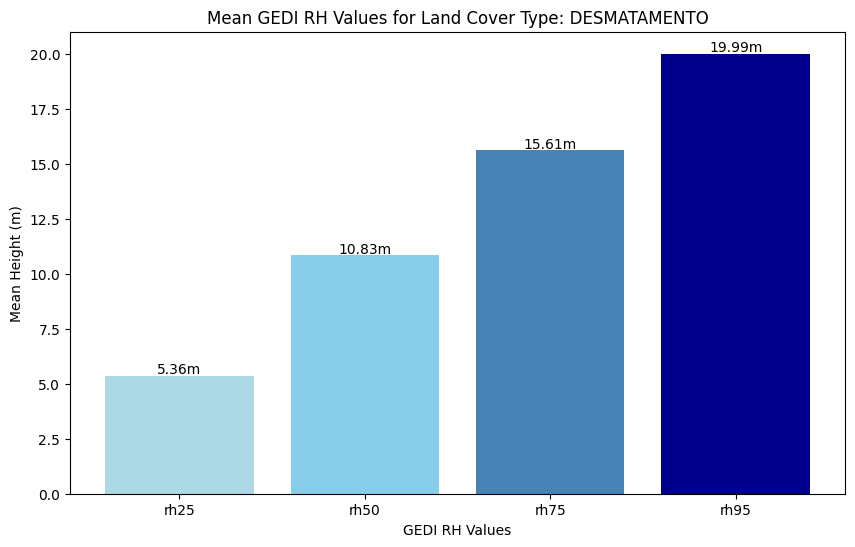

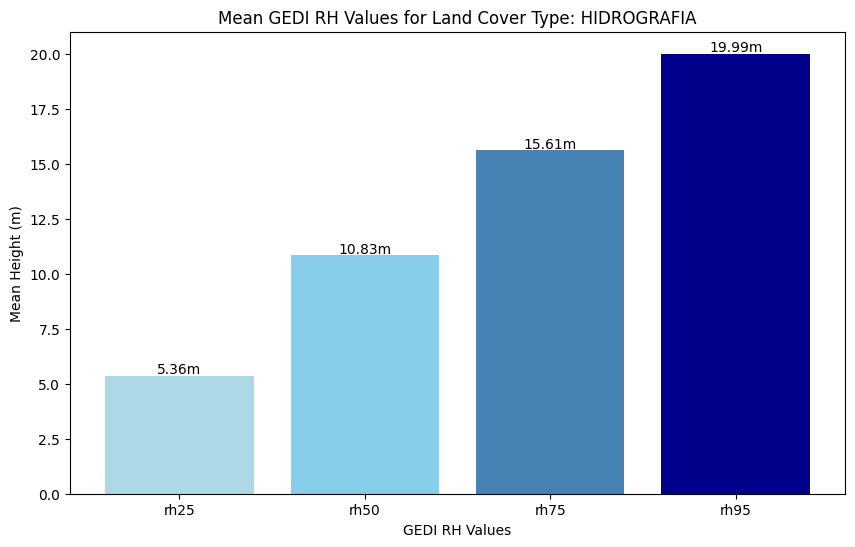

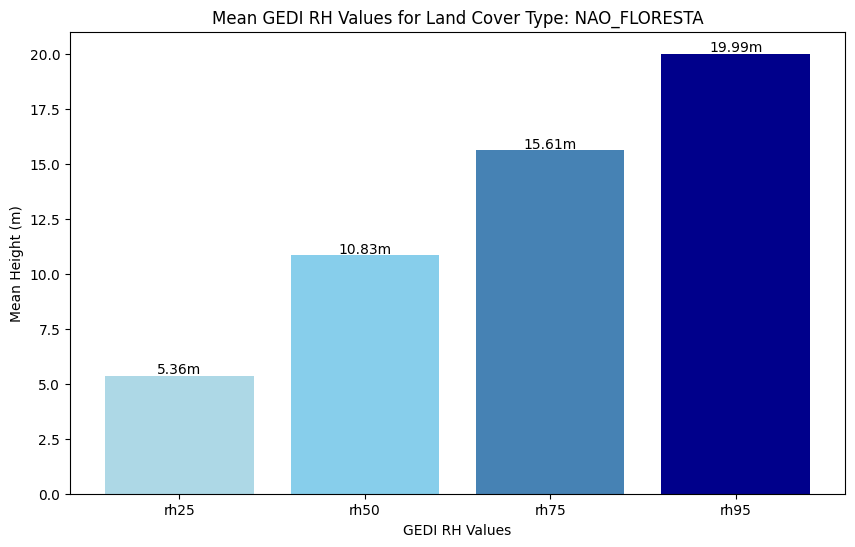

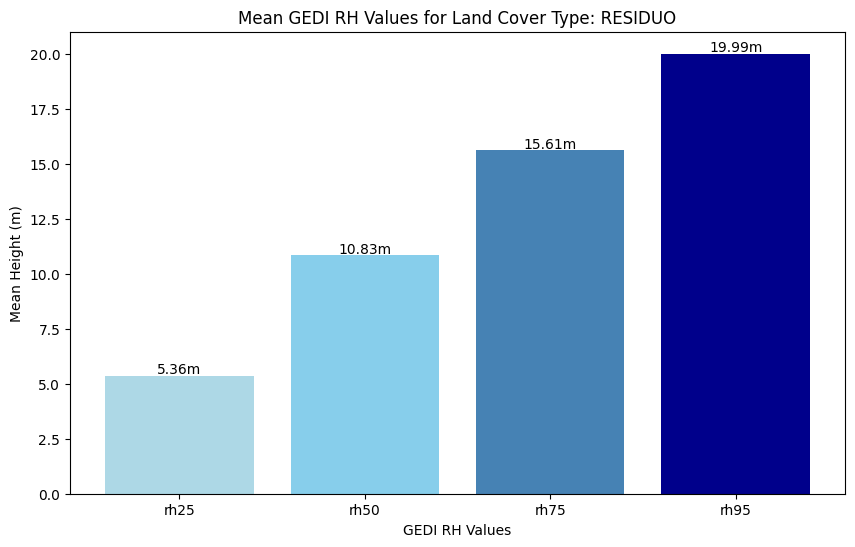

In [ ]:
# Create barchart of avg rh values based on land cover type
land_types = matched_gdf['main_class'].unique()

for land_type in land_types:
    barplot_data = matched_gdf[matched_gdf['main_class'] == land_type]

    rh_values = ['rh25', 'rh50', 'rh75', 'rh95']
    mean_values = []
    for val in rh_values:
        mean_values.append(barplot_data[val].dropna().mean())
    
    plt.figure(figsize=(10, 6))
    plt.bar(x = rh_values, height = mean_values, color=['lightblue', 'skyblue', 'steelblue', 'darkblue'])

    for i, mean_val in enumerate(mean_values):
        plt.text(i, mean_val + 0.1, f'{mean_val:.2f}m', ha='center')

    plt.xlabel('GEDI RH Values')
    plt.ylabel('Mean Height (m)')
    plt.title(f'Mean GEDI RH Values for Land Cover Type: {land_type}')
    
    plt.show()

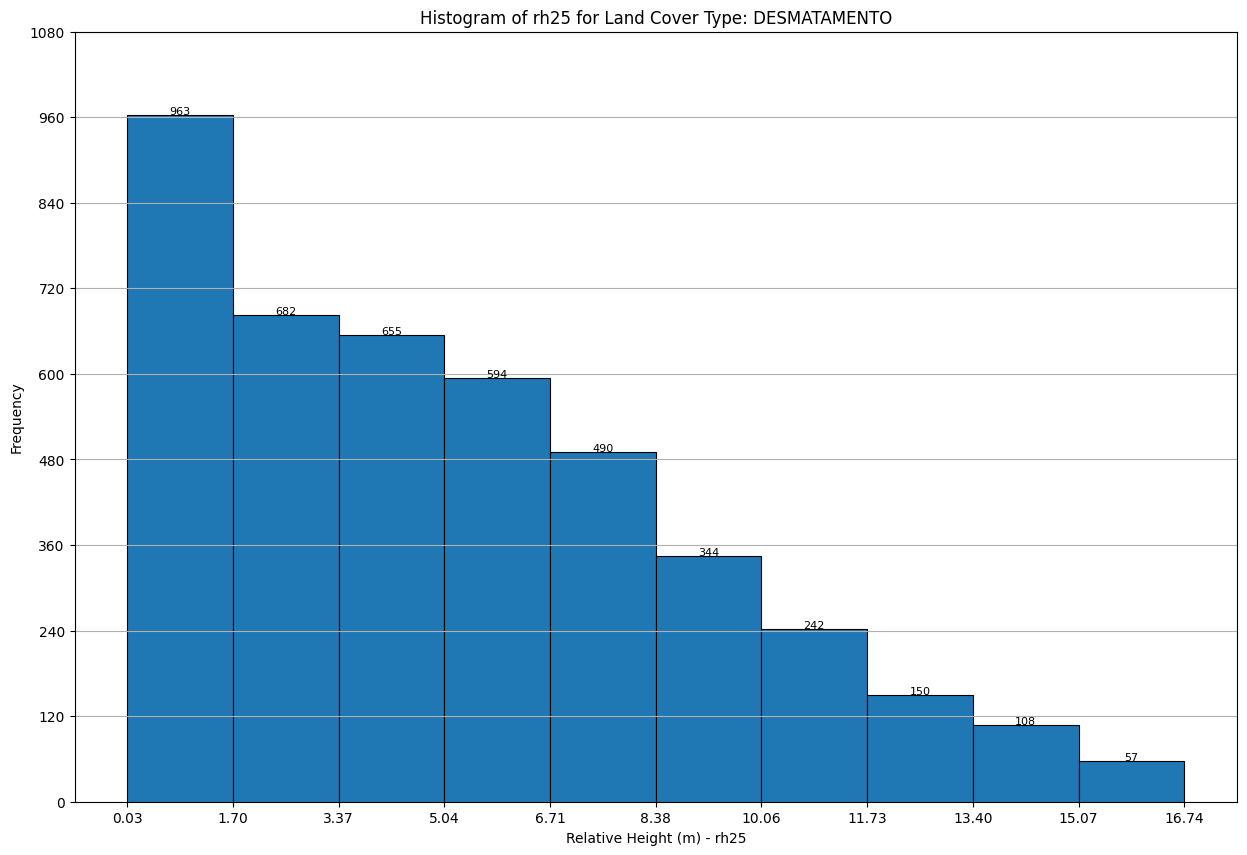

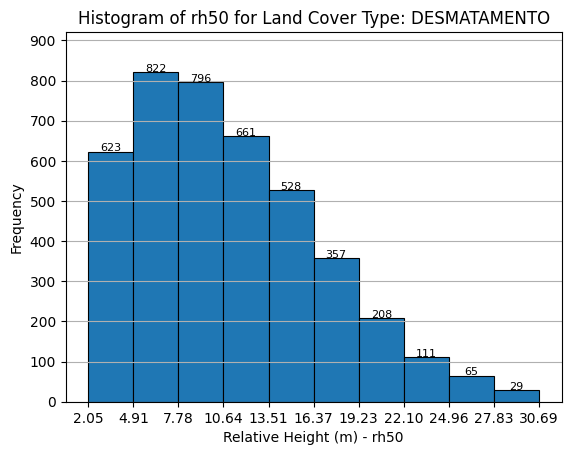

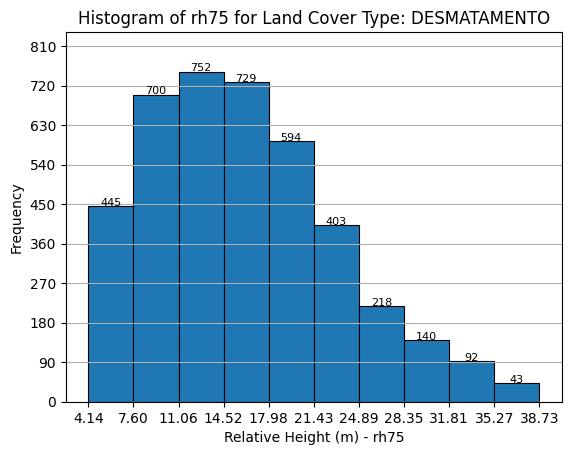

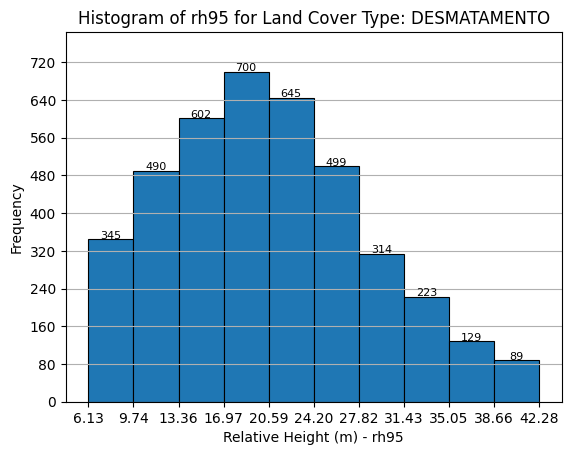

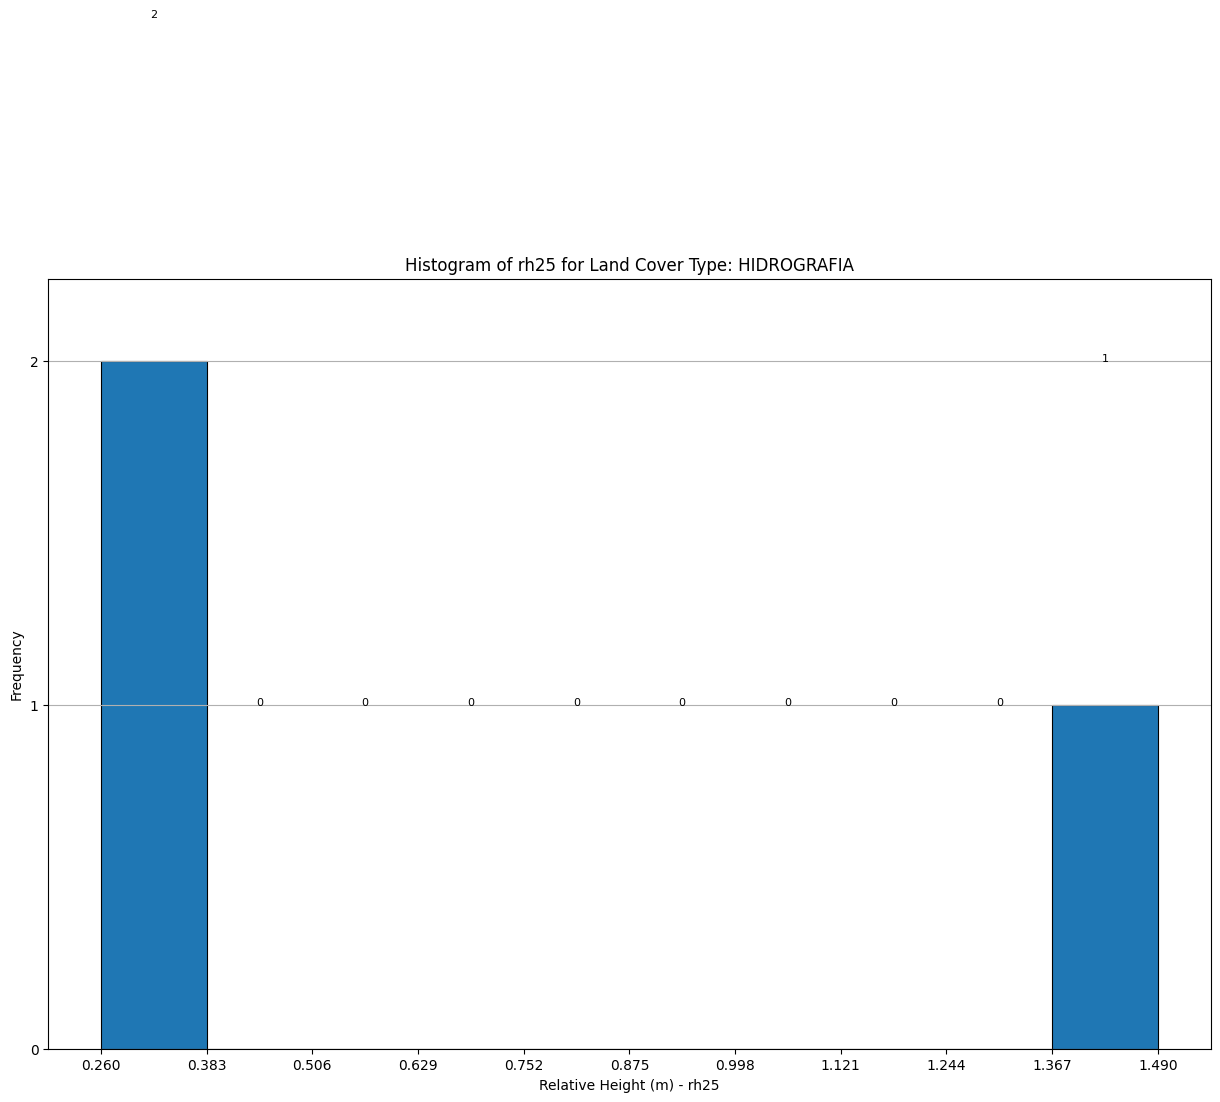

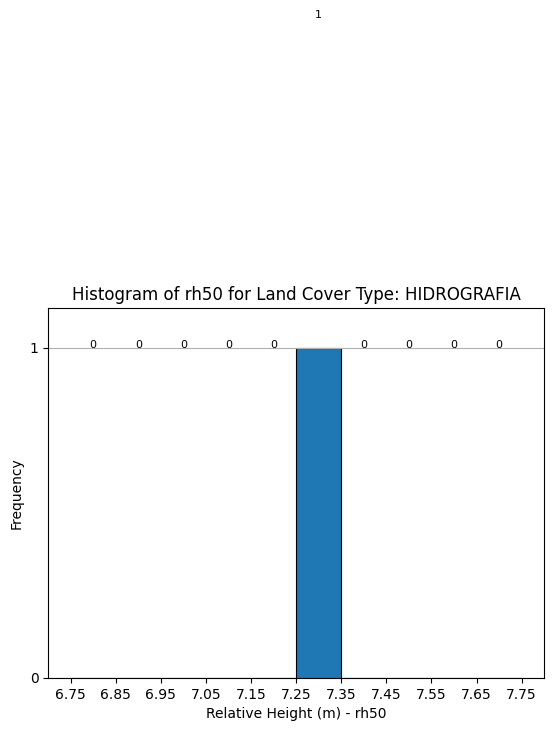

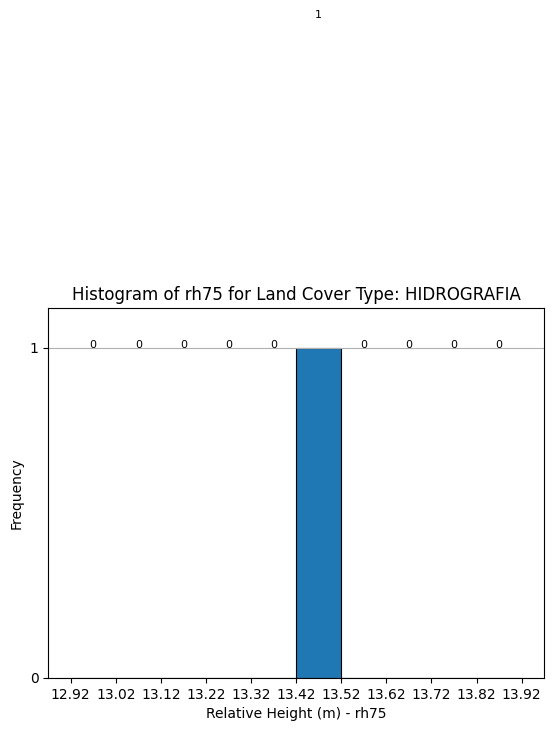

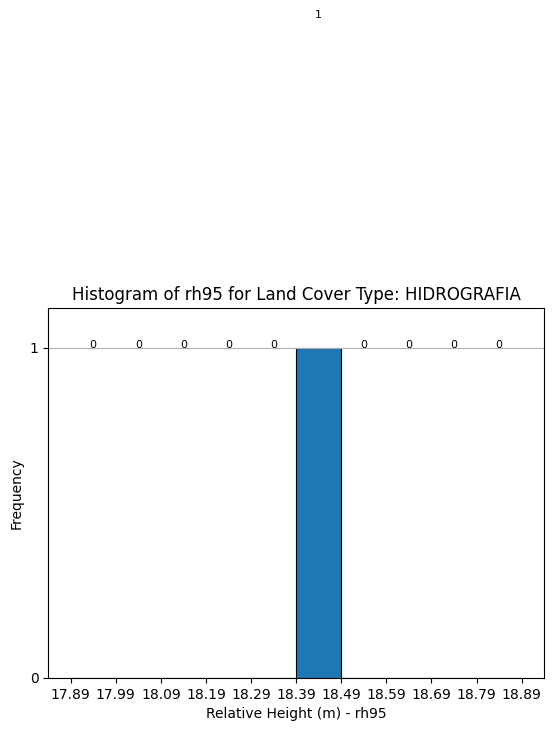

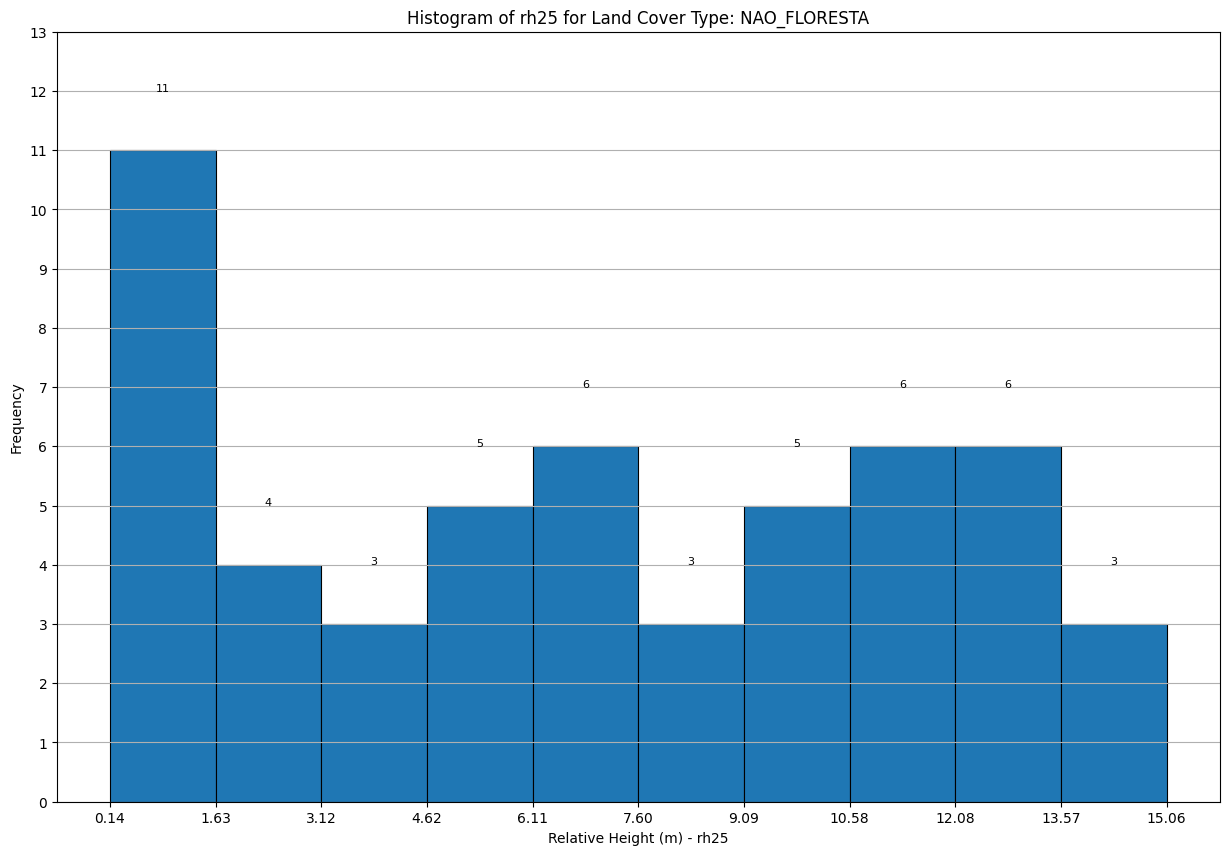

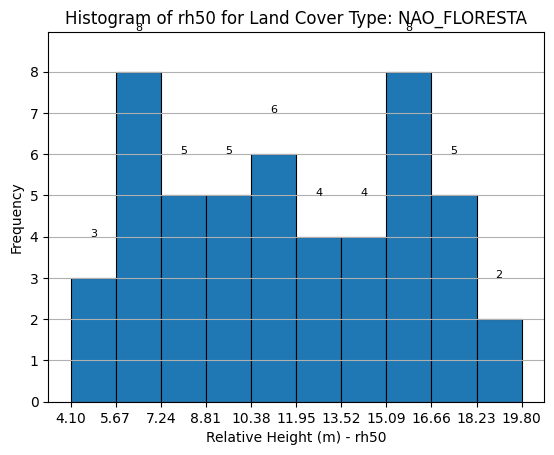

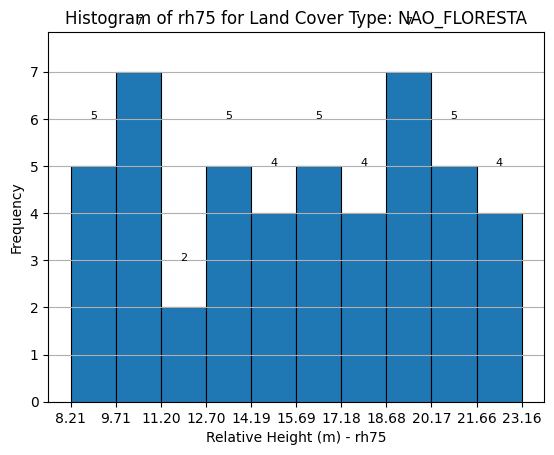

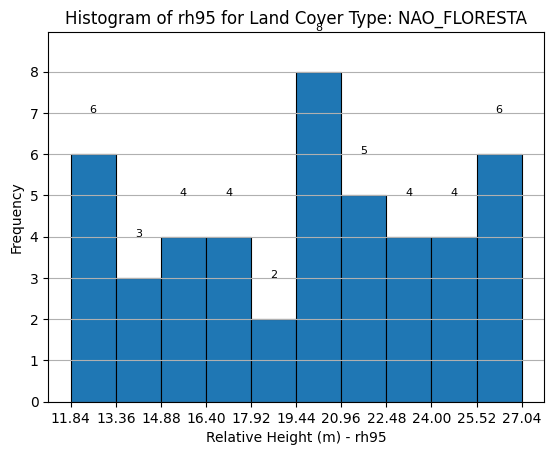

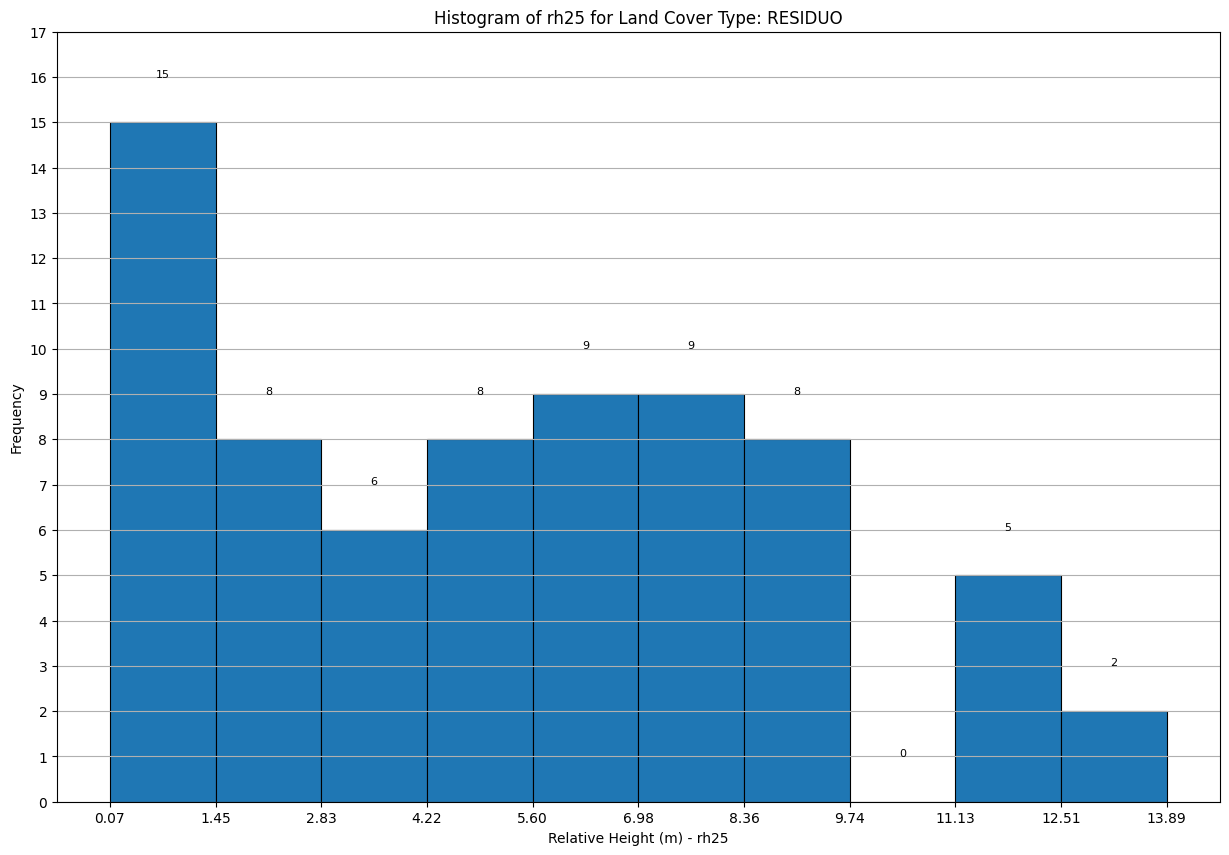

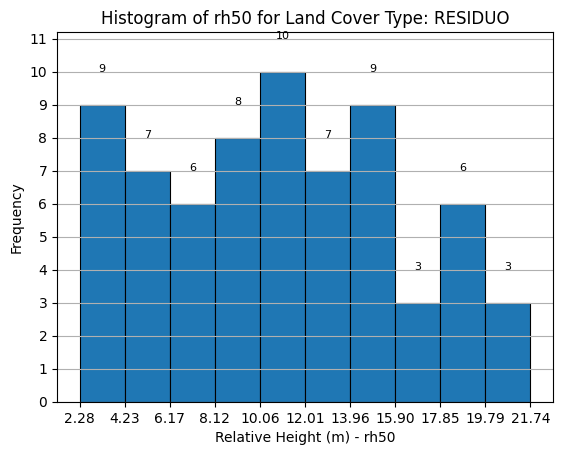

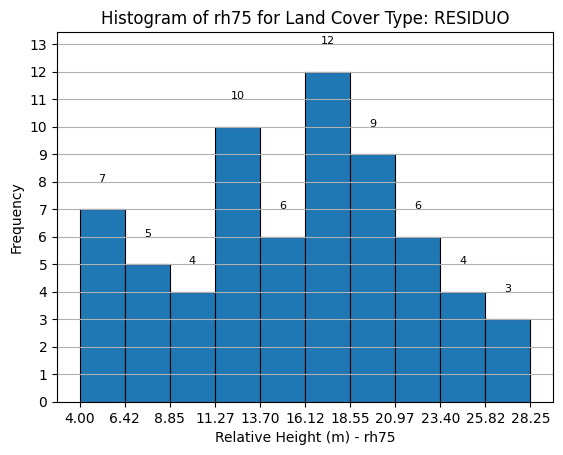

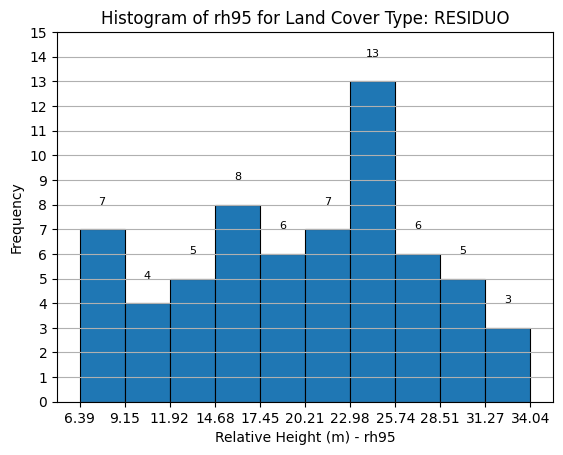

In [ ]:
# Create histograms based on different RH values 
land_types = matched_gdf['main_class'].unique()

for land_type in land_types:
    hist_data = matched_gdf[matched_gdf['main_class'] == land_type]
    rh_cols = [col for col in matched_gdf.columns if col.startswith('rh')]
    
    plt.figure(figsize=(15, 10))
    for rh_col in rh_cols:
        upper_outlier = hist_data[rh_col].dropna().quantile(0.99)
        hist_data = hist_data[hist_data[rh_col] <= upper_outlier] # remove upper 1% outliers
        lower_outlier = hist_data[rh_col].dropna().quantile(0.01)
        hist_data = hist_data[hist_data[rh_col] >= lower_outlier] # remove lower 1% outliers
        hist_data = hist_data[hist_data[rh_col] > 0] # remove negative values
        
        counts, bins, patches = plt.hist(x = hist_data[rh_col].dropna(), edgecolor='black', linewidth=0.8)  

        max_count = counts.max() if len(counts) else 0
        plt.ylim(0, max(plt.ylim()[1], max_count * 1.12))  # add room for labels
        
        # list counts at top of each bar if there are more than 5 bars
        if len(patches) > 5:
            for i in range(len(patches)):
                plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 1, str(int(counts[i])), ha='center', fontsize = 8)

        plt.title(f'Histogram of {rh_col} for Land Cover Type: {land_type}')
        plt.xlabel(f'Relative Height (m) - {rh_col}')
        plt.ylabel('Frequency')

        # dynamically add y ticks for readability
        locs, labels = plt.yticks()
        plt.yticks(np.arange(0, max(locs), step=max(1, int(max(locs)/10))))

        plt.xticks(bins)

        plt.grid(True) 
        plt.grid(axis='x')

        plt.show()